# Bijective TransformsWorking with bijective transformations for normalizing flows.

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import jax
import jax.numpy as jnp
import numpy as np

from probjax.nn.nets.normalizing_flows import rational_quadratic_spline

jax.config.update("jax_platform_name", "cpu")

In [3]:
from jax._src.prng import PRNGKeyArray

In [13]:
from probjax.core import inverse

def f(x):
    return rational_quadratic_spline(jnp.ones((9,)), x)
f(0.5)

inverse(jax.vmap(f))(jnp.ones((100,)))

Array([1.3103924, 1.3103924, 1.3103924, 1.3103924, 1.3103924, 1.3103924,
       1.3103924, 1.3103924, 1.3103924, 1.3103924, 1.3103924, 1.3103924,
       1.3103924, 1.3103924, 1.3103924, 1.3103924, 1.3103924, 1.3103924,
       1.3103924, 1.3103924, 1.3103924, 1.3103924, 1.3103924, 1.3103924,
       1.3103924, 1.3103924, 1.3103924, 1.3103924, 1.3103924, 1.3103924,
       1.3103924, 1.3103924, 1.3103924, 1.3103924, 1.3103924, 1.3103924,
       1.3103924, 1.3103924, 1.3103924, 1.3103924, 1.3103924, 1.3103924,
       1.3103924, 1.3103924, 1.3103924, 1.3103924, 1.3103924, 1.3103924,
       1.3103924, 1.3103924, 1.3103924, 1.3103924, 1.3103924, 1.3103924,
       1.3103924, 1.3103924, 1.3103924, 1.3103924, 1.3103924, 1.3103924,
       1.3103924, 1.3103924, 1.3103924, 1.3103924, 1.3103924, 1.3103924,
       1.3103924, 1.3103924, 1.3103924, 1.3103924, 1.3103924, 1.3103924,
       1.3103924, 1.3103924, 1.3103924, 1.3103924, 1.3103924, 1.3103924,
       1.3103924, 1.3103924, 1.3103924, 1.3103924, 

In [6]:
NUM_BINS = 10


In [7]:
for _ in range(100):
    params = np.random.randn(NUM_BINS*3)
    x = np.random.randn(1)

    y = linear_spline(params, x)
    x_rec, logdet = linear_spline.inv_and_logdet(params, y)
    assert jnp.isfinite(y)
    assert jnp.isfinite(x_rec)
    assert jnp.isfinite(logdet)
    assert jnp.allclose(x, x_rec, atol=1e-1)


NameError: name 'linear_spline' is not defined

In [5]:
x_rec, x

(Array([-6.553], dtype=float32), array([0.902]))

In [ ]:
params.min(), params.max()

(np.float64(-2.414662156409944), np.float64(2.587241401633493))

In [12]:
from functools import partial


x_line = jnp.linspace(0, 1, 1000)
params = np.random.randn(1000, NUM_BINS*3)
params1 = np.random.randn(100,NUM_BINS)
params2 = np.random.randn(100,NUM_BINS).cumsum(-1)
params3 = np.random.randn(100,NUM_BINS)
params = jnp.concatenate([params1, params2, params3], axis=1)
_f = jax.vmap(partial(linear_spline, range_min_y=0, range_max_y=1, range_min_x=0., range_max_x=1., bounded=True), in_axes=(None, 0))
__f = jax.vmap(_f, in_axes=(0, None))

y_lines = __f(params, x_line)

assert jnp.isfinite(y_lines).all()

(0.0, 1.0)

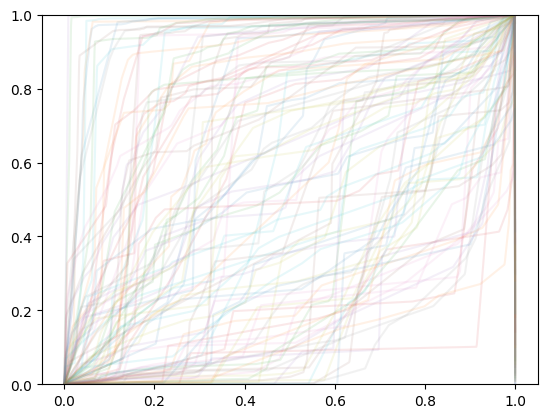

In [ ]:
import matplotlib.pyplot as plt
_ = plt.plot(x_line, y_lines.T, alpha=0.1)
plt.ylim(0, 1)